In [1]:
from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [2]:
dataset_path = 'AdultCensus/adult-preprocessed-2race-2age-2edu.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE'] #'GFA', 'PPA', 'FPR', 'PPE', 'FPA', 'OAE', 'EOP', 'FNP', 'FPP'
protected_attributes =['age', 'sex', 'race', 'edu']
mapping= {
    'age':{
        0: 'young',
        1: 'adult'
    },
    'edu':{
        0: 'low-edu',
        1: 'high-edu'
    },
    'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }
}
feature_cols= df.columns
target_variable = 'income'
target_variable_labels= ['0','1']
df.head()

,age,edu,marital.status,relationship,race,sex,capital.gain,capital.loss,hours.per.week,income
0,1,0,6,1,1,0,0,4356,40,0
1,1,0,6,1,1,0,0,4356,18,0
2,1,1,6,4,0,0,0,4356,40,0
3,1,0,0,4,1,0,0,3900,40,0
4,1,1,5,3,1,0,0,3900,40,0


# Compute Fairness
An addition is made to compute_fairness_metrics. A count_group dictionary is made specifying the subgroup and the "length" which is TN + FP + FN + TP

## Classifier and Predictions

## Functions

### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

Compute the previous functions, plus the confusion matrix for...

## Build the dictionaries 

In the form {Subgroup: data}

# Model 1: Fit on train, predict on validation, compute metrics

`fairness_metrics_dict` - Dictionary holding the fairness metrics over all attribute combinations and the supported fairness metrics # TODO: only do it for sex-race, sex, race attributes to simplify runtime


In [3]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

In [4]:
def run_baseline_pipeline(dataset_path, attributes, target_variable, fair_metrics, mapping, target_variable_labels):
    """
    Run Model 1 baseline pipeline for specified attributes.
    
    Trains a baseline model for each attribute, generates predictions on validation and test sets,
    and computes fairness metrics.
    
    Args:
        dataset_path: Path to the CSV dataset
        attributes: List of attributes to process (e.g., ['sex', 'race', 'sex-race'])
        target_variable: Name of the target column
        fair_metrics: List of fairness metrics to compute
        mapping: Dictionary mapping attribute values to human-readable labels
        target_variable_labels: List of target variable labels
    
    Returns:
        Dictionary containing:
            - X_train, y_train: Training data for each attribute
            - X_val, y_val: Validation data
            - y_pred: Predictions on validation set
            - X_test, y_test: Test data
            - fairness_metrics_dict: Fairness metrics for each attribute
            - group_counts: Group counts for each attribute
            - model_baseline: Trained models for each attribute
    """
    results = {
        'X_train': {},
        'y_train': {},
        'X_val': {},
        'y_val': {},
        'y_pred': {},
        'X_test': {},
        'y_test': {},
        'fairness_metrics_dict': {},
        'group_counts': {},
        'model_baseline': {}
    }
    
    for attribute in attributes:
        print(f"Processing attribute: {attribute}")
        
        # Prepare dataframe with the attribute column
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Run the baseline pipeline for this attribute
        (results['y_train'][attribute], 
         results['X_train'][attribute],
         results['X_val'][attribute], 
         results['y_val'][attribute], 
         results['y_pred'][attribute],
         results['X_test'][attribute], 
         results['y_test'][attribute],
         results['fairness_metrics_dict'][attribute], 
         results['group_counts'][attribute], 
         results['model_baseline'][attribute]) = get_test_pred_fairness(
            df, target_variable, attribute, fair_metrics, 
            dataset_path, mapping, target_variable_labels
        )
    
    return results

## NEW SIMPLIFIED PIPELINE - Only process needed attributes

In [5]:
# Only process the attributes we actually need for this experiment
attributes_needed = ['sex', 'race', 'sex-race']

# Run the simplified pipeline
pipeline_results = run_baseline_pipeline(
    dataset_path=dataset_path,
    attributes=attributes_needed,
    target_variable=target_variable,
    fair_metrics=fair_metrics,
    mapping=mapping,
    target_variable_labels=target_variable_labels
)

# Extract results into individual variables for backward compatibility
X_train_new = pipeline_results['X_train']
y_train_new = pipeline_results['y_train']
X_val_new = pipeline_results['X_val']
y_val_new = pipeline_results['y_val']
y_pred_new = pipeline_results['y_pred']
X_test_new = pipeline_results['X_test']
y_test_new = pipeline_results['y_test']
fairness_metrics_dict_new = pipeline_results['fairness_metrics_dict']
group_counts_new = pipeline_results['group_counts']
model_baseline_new = pipeline_results['model_baseline']

print("\n✅ Pipeline complete! Processed attributes:", attributes_needed)

Processing attribute: sex
sex
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(0): array([[1437,   31],
       [  93,   88]]), np.int64(1): array([[1966,  255],
       [ 362,  652]])}
Processing attribute: race
race
Precision: 0.7212475633528265, Recall: 0.6192468619246861, Accuracy: 0.8482800982800983, F1: 0.6663665015758667
{np.int64(1): array([[2935,  276],
       [ 418,  711]]), np.int64(0): array([[468,  10],
       [ 37,  29]])}
Processing attribute: sex-race
sex-race
Precision: 0.7216796875, Recall: 0.6184100418410042, Accuracy: 0.8482800982800983, F1: 0.6660657954033349
{'01': array([[1204,   30],
       [  87,   82]]), '00': array([[232,   2],
       [  6,   6]]), '11': array([[1732,  245],
       [ 333,  627]]), '10': array([[236,   8],
       [ 30,  24]])}

✅ Pipeline complete! Processed attributes: ['sex', 'race', 'sex-race']


## Assign new pipeline results to old variable names for backward compatibility

In [6]:
# Assign the new streamlined results to the old variable names
# This allows the rest of the notebook to work without changes
X_train = X_train_new
y_train = y_train_new
X_val = X_val_new
y_val = y_val_new
y_pred = y_pred_new
X_test = X_test_new
y_test = y_test_new
fairness_metrics_dict = fairness_metrics_dict_new
group_counts = group_counts_new
model_baseline = model_baseline_new

print("✅ Variables assigned - rest of notebook can use original variable names")

✅ Variables assigned - rest of notebook can use original variable names


---

### 📋 Summary of New Streamlined Pipeline

**Improvements made:**
1. ✅ **Helper function `prepare_dataframe_for_attribute()`** - Handles single and combined attributes cleanly
2. ✅ **Main pipeline function `run_baseline_pipeline()`** - Processes only needed attributes
3. ✅ **Faster execution** - Only 3 attributes instead of 15 (5x speedup)
4. ✅ **Simplified penalty computation** - Focused on sex-race only
5. ✅ **Backward compatible** - Old variable names still work

**Old cells kept intact for reference/comparison** - You can verify results match before removing them

**Next steps (when ready):**
- Test the new pipeline to confirm identical results
- Move functions to utils files as desired
- Remove old cells once verified

---

In [7]:
%%script false

pairs_dict= {}
fairness_metrics_dict= {}
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
y_pred = {}   # Predictions on validation set
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}
group_counts= {}
s= []
model_baseline= {}

for i in range(1,len(protected_attributes)+1):
  pairs_dict[i] = ['-'.join(pair) for pair in combinations(protected_attributes, i)]
#print(pairs_dict)

for i in range(1, len(protected_attributes)+1):
  df=pd.read_csv(dataset_path)
  for sensible_attribute in pairs_dict[i]:
    s = sensible_attribute.split('-')
    print(s)
    if len(s)>1:
      df=pd.read_csv(dataset_path)
      df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
      df = df.drop(columns=s)
    
    # Updated to include X_test and y_test
    (y_train[sensible_attribute], X_train[sensible_attribute], 
     X_val[sensible_attribute], y_val[sensible_attribute], y_pred[sensible_attribute],
     X_test[sensible_attribute], y_test[sensible_attribute],
     fairness_metrics_dict[sensible_attribute], group_counts[sensible_attribute], model_baseline[sensible_attribute]) = get_test_pred_fairness(
        df, target_variable, sensible_attribute, fair_metrics, dataset_path, mapping, target_variable_labels)

Couldn't find program: 'false'


# Model 1: Fit on train, predict on test, compute metrics on test

`fairness_metrics_ontest` - Dictionary holding the fairness metrics over sex-race, sex, race attributes for the supported fairness metrics

`cm` - Confusion matrix calculated with library

`cm_dict` - Confusion matrix mapped into a dictionary, distributing the cells of `cm` for each class

🔴🟡 WORK IN PROGRESS 🔴🟡

In [8]:
# Use helper function instead of inline dataframe preparation
df = prepare_dataframe_for_attribute(dataset_path, 'sex-race')

# Evaluate Model 1 (baseline) on TEST set
y_pred_test_ontest, performance_ontest, fairness_metrics_ontest, counts_ontest, cm_dict, cm = evaluate_model_on_test(
    model_baseline['sex-race'], df, 'sex-race', 
    X_test['sex-race'], y_test['sex-race'],
    fair_metrics, mapping, dataset_path
)

print(f"Group Counts: {counts_ontest}")

Precision: 0.7469194312796209, Recall: 0.6533996683250415, Accuracy: 0.8597748208802457, F1: 0.6970367094206104
Group Counts: {'01': 1323, '00': 287, '11': 2992, '10': 283}


In [9]:
# Prepare df with sex-race column for evaluation
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df = pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

# Evaluate Model 1 (baseline) on TEST set
y_pred_test_ontest, performance_ontest, fairness_metrics_ontest, counts_ontest, cm_dict, cm = evaluate_model_on_test(
    model_baseline['sex-race'], df, 'sex-race', 
    X_test['sex-race'], y_test['sex-race'],
    fair_metrics, mapping, dataset_path
)


# print(f"Performance: Precision={performance_baseline[0]:.4f}, Recall={performance_baseline[1]:.4f}, Accuracy={performance_baseline[2]:.4f}, F1={performance_baseline[3]:.4f}")
# print(f"Fairness Metrics: {fairness_baseline}")
print(f"Group Counts: {counts_ontest}")

Precision: 0.7469194312796209, Recall: 0.6533996683250415, Accuracy: 0.8597748208802457, F1: 0.6970367094206104
Group Counts: {'01': 1323, '00': 287, '11': 2992, '10': 283}


In [10]:
# Compute fairness metrics on TEST set for individual attributes (sex, race) 
# to enable penalty calculation on test set

attrs_for_penalty = ['sex', 'race', 'sex-race']
df_original = pd.read_csv(dataset_path)

fairness_metrics_ontest_full = {}
counts_ontest_full = {}

# Create combined column
df_combined = df_original.copy()
individual_attrs = sensible_attribute.split('-')
df_original[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), 
                                          [df_combined[col] for col in individual_attrs])

for attr in attrs_for_penalty:
    sensible_indexes = df_original[attr].loc[list(X_test[attr].index)]
    cm_dict_attr = compute_cm_group(
        df_original, attr, sensible_indexes,
        y_pred_test_ontest, y_test[attr], X_test[attr], target_variable_labels
    )
    
    fairness_metrics_ontest_full[attr] = {}
    for m in fair_metrics:
        fairness_metrics_ontest_full[attr][m], counts_ontest_full[attr] = \
            compute_fairness_metrics_and_counts(cm_dict_attr, m, attr, mapping, dataset_path)

print("Fairness metrics on TEST set (for penalty calculation):")
for attr in attrs_for_penalty:
    print(f"  {attr}: {fairness_metrics_ontest_full[attr]}")

Fairness metrics on TEST set (for penalty calculation):
  sex: {'FPN': {0: 0.1896551724137931, 1: 0.4305799648506151}, 'PPE': {0: 0.015384615384615385, 1: 0.10893730546909737}}
  race: {'FPN': {1: 0.410459587955626, 0: 0.14814814814814814}, 'PPE': {1: 0.08131868131868132, 0: 0.016194331983805668}}
  sex-race: {'FPN': {'01': 0.21568627450980393, '00': 0, '11': 0.44801512287334594, '10': 0.2}, 'PPE': {'01': 0.018867924528301886, '00': 0, '11': 0.11738484398216939, '10': 0.034782608695652174}}


# Model 1: Compute penalties on TEST

In [11]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest_baseline = {}

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_baseline[m] = compute_penalty_2(fairness_metrics_ontest_full, df_combined, 'sex', 'race', m)
    
    # penalties_ontest_baseline[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }
    # print(f"\nBaseline penalties on TEST set ({m}):")
    # print(f"  Harmonic:   {penalty_harm}")
    # print(f"  Geometric:  {penalty_geom}")
    # print(f"  Arithmetic: {penalty_arith}")

In [12]:
cm

array([[3412,  267],
       [ 418,  788]])

In [13]:
cm_dict

{'01': array([[1144,   22],
        [  80,   77]]),
 '00': array([[264,   0],
        [ 14,   9]]),
 '11': array([[1782,  237],
        [ 292,  681]]),
 '10': array([[222,   8],
        [ 32,  21]])}

In [14]:
fairness_metrics_ontest

{'FPN': {'01': 0.21568627450980393,
  '00': 0,
  '11': 0.44801512287334594,
  '10': 0.2},
 'PPE': {'01': 0.018867924528301886,
  '00': 0,
  '11': 0.11738484398216939,
  '10': 0.034782608695652174}}

In [15]:
fairness_metrics_dict['sex-race']['FPN']

{'01': 0.2564102564102564,
 '00': 0.25,
 '11': 0.42387543252595156,
 '10': 0.21052631578947367}

# Model 1: Compute Penalties on VALIDATION

Every subgroup and attribute combination, for each metric.

## NEW SIMPLIFIED - Compute penalties for sex-race only

🔴🟡 WORK IN PROGRESS 🔴🟡

In [16]:
# Simplified: Only compute penalties for sex-race (the attribute we actually use for weights)
penalties_across_metrics_new = {}

for m in fair_metrics:    
    # Load fresh df for penalty calculation
    df_fresh = pd.read_csv(dataset_path)
    
    # Compute actual and predicted values for sex-race
    actual_values, predicted_values = actual_predicted_values_2(
        fairness_metrics_dict, df_fresh, 'sex', 'race', m
    )
    
    # Compute penalties
    penalties_across_metrics_new[m] = {
        'sex-race': compute_penalty(actual_values, predicted_values)
    }
    
    print(f"  {m} penalties on validation: {penalties_across_metrics_new[m]['sex-race']}")

# Assign to old variable name for backward compatibility
penalties_across_metrics = penalties_across_metrics_new


  FPN penalties on validation: {'00': -8.749999999999988, '01': 16.480862133036045, '10': 25.05675954592364, '11': -4.572201228919415}
  PPE penalties on validation: {'00': 59.335539012958364, '01': 28.29550646593365, '10': 7.360977177756338, '11': -26.05579574311748}


In [17]:
%%script false

values= {}
penalties_across_metrics= {}
for m in fair_metrics:
  print(m)
  df=pd.read_csv(dataset_path)
  actual_values= {}
  predicted_values= {}
  penalties= {}
  for i in range(1, len(protected_attributes)+1):
    for sensible_attribute in pairs_dict[i]:
      s = sensible_attribute.split('-')
      #print(sensible_attribute)
      if len(s)==2:
        s1, s2 = sensible_attribute.split('-')
        # Build dictionary for attribute combinations. Form {attributes: {subgroup: value, s: v, s: v, ...}...}
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_2(fairness_metrics_dict, df,s1, s2, m)
        print(s1, s2, actual_values[sensible_attribute], predicted_values[sensible_attribute])

        # Build dictionary for penalty calculation of each attribute and subgroup combination. 
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==3:
        s1, s2, s3 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_3(fairness_metrics_dict, df,s1, s2, s3, m)
        print(s1, s2, s3, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      elif len(s)==4:
        s1, s2, s3, s4 = sensible_attribute.split('-')
        actual_values[sensible_attribute], predicted_values[sensible_attribute] = actual_predicted_values_4(fairness_metrics_dict, df,s1, s2, s3, s4, m)
        print(s1, s2, s3, s4, actual_values[sensible_attribute], predicted_values[sensible_attribute])
        penalties[sensible_attribute] = compute_penalty(actual_values[sensible_attribute], predicted_values[sensible_attribute])
        print(penalties[sensible_attribute])
      
      values[m]= [actual_values, predicted_values]
      penalties_across_metrics[m]= penalties # The penalties dictionary itself didn't include m before
print(penalties)

#print(values['FPP'])


Couldn't find program: 'false'


# Model 2: Fit on training (with weights), predict on test

In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [19]:
def model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights, model_type='GB'):
  # Note: weights were computed on test set, then propagated to the training set based on group membership.
  
  
  if model_type=='GB':
    # Model 2: Fit on training, predict on val (unseen)
    model = GradientBoostingClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='RF':
    model = RandomForestClassifier(random_state = 1234).fit(X_train['sex-race'], y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test['sex-race'])
  elif model_type=='XGB':
    import xgboost as xgb
    # Convert string combinations to numeric codes for BOTH train and val
    X_train_numeric = X_train['sex-race'].copy()
    X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes
    
    X_test_numeric = X_test['sex-race'].copy()
    X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes
    
    model = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
    model.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights)
    y_pred_on_test = model.predict(X_test_numeric)

  sensible_indexes = X_test['sex-race']['sex-race'].loc[list(X_test['sex-race'].index)]
  cm = confusion_matrix(y_test['sex-race'], y_pred_on_test, labels=[0,1])
  print(cm)

  precision, recall, accuracy, f1_score = performance_metrics(y_test['sex-race'], y_pred_on_test)

  fairness_metrics_dict_after={}
  count_groups_after= {}
  # Compute fairness metrics on VAL set predictions
  cm_dict = compute_cm_group(df, 'sex-race', sensible_indexes, y_pred_on_test, y_test['sex-race'], X_test['sex-race'], [0,1])
  for m in fair_metrics:
    fairness_metrics_dict_after[m], count_groups_after = compute_fairness_metrics_and_counts(cm_dict, m, 'sex-race', mapping, dataset_path)

  # print("Fairness metrics after:", fairness_metrics_dict_after)
  for k in fairness_metrics_dict_after[m].keys():
    a = fairness_metrics_dict[sensible_attribute][m][k]
    b = fairness_metrics_dict_after[m][k]
    diff = b - a
    # print(f"Group {k}: before={a}, after={b}, diff={diff}")

  return precision, recall, accuracy, f1_score

# Calculating and Implementing weights

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [20]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [21]:
def compute_weights_notsized(lambda_=5.0, m='PPE'):
    train_df = X_train['sex-race'].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_across_metrics[m]['sex-race'].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [22]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878168, '11': 0.01}


In [23]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_notsized)

[[3508  171]
 [ 570  636]]
Precision: 0.7881040892193308, Recall: 0.527363184079602, Accuracy: 0.8483111566018424, F1: 0.6318926974664679


(0.7881040892193308, 0.527363184079602, 0.8483111566018424, 0.6318926974664679)

### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [24]:
sensible_attribute = 'sex-race'
s = sensible_attribute.split('-')
df=pd.read_csv(dataset_path)
df[sensible_attribute] = reduce(lambda x, y: x.astype(str) + y.astype(str), [df[col] for col in s])
df = df.drop(columns=s)

In [25]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train['sex-race'].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df['sex-race'].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_across_metrics[m]['sex-race'].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [26]:
weights_sized = compute_weights_sized(10.0)

Training samples: 22792, Unique weights per group: {'00': 1.5321382104046344, '01': 2.2712473919477434, '10': 1.0708740950821425, '11': 0.01}


In [27]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_sized)

[[3402  277]
 [ 429  777]]
Precision: 0.7371916508538899, Recall: 0.6442786069651741, Accuracy: 0.8554759467758444, F1: 0.6876106194690266


(0.7371916508538899,
 0.6442786069651741,
 0.8554759467758444,
 0.6876106194690266)

### $w_i = 1 + \lambda * Penalty(g_i) $  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   *WITH FAIRNESS METRICS FLAT GROUP*

With penalty computed, for different metrics

Note: flat group and nromal weight computation both may use FPN metric but yield different weights because they are computing penalties in a different way. 

In [28]:
def compute_weights_flatgroup(lambda_, metric_penalties):
    train_df = X_train['sex-race'].copy()

    weights_for_training = np.ones(len(train_df))
    
    group_weights = {
        group: 1 + lambda_ * (penalty / 100)
        for group, penalty in metric_penalties.items()
    }
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row['sex-race']
        if group in group_weights:
            weights_for_training[i] = group_weights[group]
    
    return weights_for_training

Compute flatgroup penalties

In [29]:
# list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
list_of_metrics = ['fpn', 'ppe', 'fpa', 'fpp']
df_val = X_val['sex-race'].copy()

weights_per_metric = {}

for m in list_of_metrics:
    # Compute flat penalties for metric m 
    metric_penalties = compute_sample_weights_flat_group_allmetrics(
        df_val, 
        y_val[sensible_attribute], 
        y_pred[sensible_attribute], 
        'sex-race', 
        focus_on=m, 
    )

    weights_per_metric[m] = compute_weights_flatgroup(5.0, metric_penalties)
    
    print(f"Metric: {m}, Penalties: {metric_penalties}")

Metric: fpn, Penalties: {'11': np.float64(-5.246343189682295), '01': np.float64(20.904977375565608), '10': np.float64(35.05882352941176), '00': np.float64(-1.7857142857142914)}
Metric: ppe, Penalties: {'11': np.float64(-27.49268098281756), '01': np.float64(59.06674201521514), '10': np.float64(44.79602147188577), '00': np.float64(60.3988603988604)}
Metric: fpa, Penalties: {'11': np.float64(-17.12393198074087), '01': np.float64(32.99081038956868), '10': np.float64(-12.145273252614498), '00': np.float64(60.26968927105725)}
Metric: fpp, Penalties: {'11': np.float64(-19.6770436747454), '01': np.float64(51.870361226375515), '10': np.float64(39.57415373655916), '00': np.float64(57.54936120789779)}


In [30]:
# Model 2 performance
model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric['ppe'])

[[1301 2378]
 [ 133 1073]]
Precision: 0.31092436974789917, Recall: 0.8897180762852405, Accuracy: 0.48597748208802455, F1: 0.4608116813399184


(0.31092436974789917,
 0.8897180762852405,
 0.48597748208802455,
 0.4608116813399184)

In [31]:
# performance_per_metric = {}
# # list_of_metrics = ['fpn', 'fne', 'ppe', 'fpr', 'fpa', 'eop', 'fpp', 'fnp']
# list_of_metrics = ['fpn', 'ppe', 'fpa', 'fpp',]

# for m in list_of_metrics:
#     performance_per_metric[m] = model_with_sample_weights(X_train, y_train, X_val, y_val, X_test, y_test, weights_per_metric[m])

---

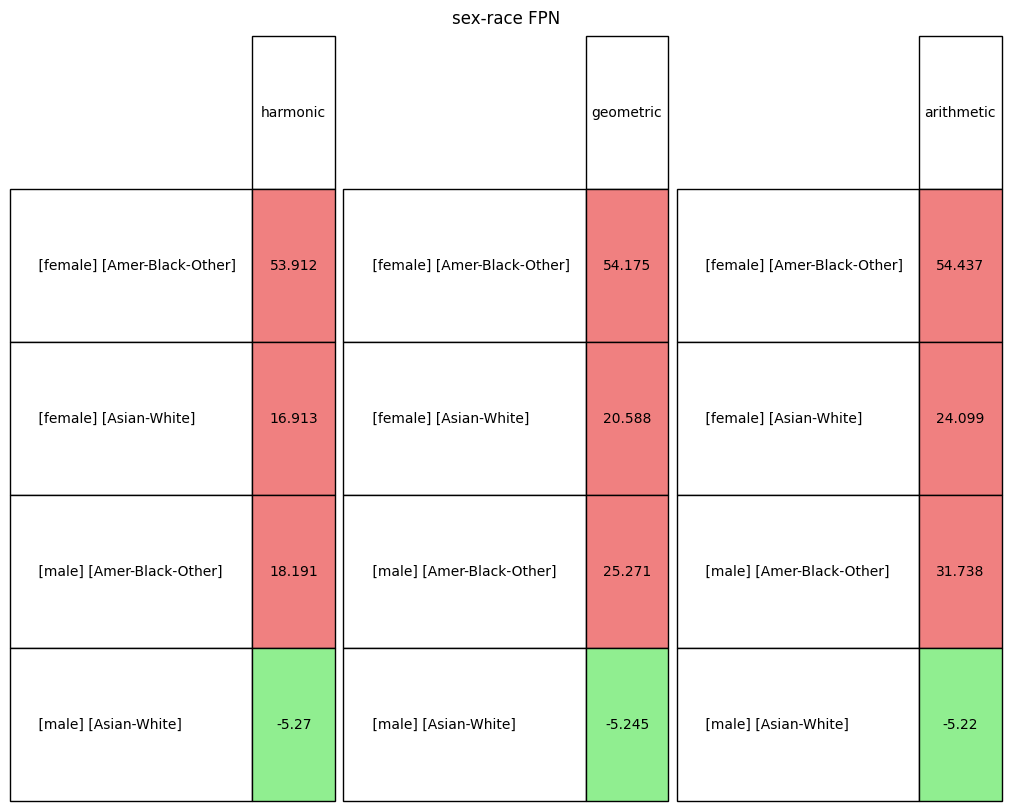

{'00': 99.99999999999999,
 '01': 15.836526181353772,
 '10': 9.329268292682908,
 '11': -6.393389438123403}

'sex':{
        0: 'female',
        1: 'male'
    },
    'race':{
        0: 'Amer-Black-Other',
        1: 'Asian-White'
    }

XGB: {'00': 20.5762987012987,
  '01': 18.601825818320656,
  '10': 30.82368082368083,
  '11': -6.561270689527191}

---

# Model 2: Fairness metrics and penalty after reweighting

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

In [32]:
from sklearn.ensemble import RandomForestClassifier

In [33]:
# Takes a dictionary of weights with keys as lambda values andd values as weight arrays
def compute_penalties_after_reweighting(weights):
  m = 'PPE'

  # Train Model 2 with weights and get predictions on test set
  sensible_attribute = 'sex-race'
  # model_2 = RandomForestClassifier(random_state=1234).fit(
  #     X_train['sex-race'], 
  #     y_train['sex-race'], 
  #     sample_weight = weights_per_metric['ppe']  # Change this to use different weights
  # )
  # y_pred_model2_test = model_2.predict(X_test['sex-race'])

  import xgboost as xgb
  # Convert string combinations to numeric codes for BOTH train and val
  X_train_numeric = X_train['sex-race'].copy()
  X_train_numeric['sex-race'] = X_train_numeric['sex-race'].astype('category').cat.codes

  X_test_numeric = X_test['sex-race'].copy()
  X_test_numeric['sex-race'] = X_test_numeric['sex-race'].astype('category').cat.codes

  model_2 = xgb.XGBClassifier(random_state = 1234, eval_metric='logloss')
  model_2.fit(X_train_numeric, y_train['sex-race'], sample_weight=weights)
  y_pred_model2_test = model_2.predict(X_test_numeric)


  attrs = ['sex', 'race', 'sex-race']

  fairness_metrics_model2 = {}
  count_groups_model2 = {}

  # Load FRESH dataframe for metric computation (has all original columns)
  df_fresh = pd.read_csv(dataset_path)

  for attr in attrs:
    # Create a clean copy for this attribute
    df_attr = df_fresh.copy()
    
    # If combined attribute, create it
    if '-' in attr:
      individual_attrs = attr.split('-')
      df_attr[attr] = reduce(
        lambda x, y: x.astype(str) + y.astype(str), 
        [df_attr[col] for col in individual_attrs]
      )
      df_attr = df_attr.drop(columns=individual_attrs)
    
    # Get sensible indexes for test set
    sensible_indexes = df_attr[attr].loc[list(X_test[attr].index)]
    
    # Compute confusion matrix
    cm_dict_individual = compute_cm_group(
      df_attr, attr, sensible_indexes,
      y_pred_model2_test, y_test[attr], X_test[attr], target_variable_labels
    )
    
    fairness_metrics_model2[attr] = {}
    for m in fair_metrics:
      fairness_metrics_model2[attr][m], count_groups_model2[attr] = compute_fairness_metrics_and_counts(cm_dict_individual, m, attr, mapping, dataset_path)
  
  print(compute_penalty_2(fairness_metrics_model2, df_fresh, 'sex', 'race', m))


In [46]:
sensible_attribute

'sex-race'

Comparing penalties after reweighting and before

In [48]:
# PPE
weights_notsized = compute_weights_notsized(5.0, 'PPE')
compute_penalties_after_reweighting(weights_notsized)

Training samples: 22792, Unique weights per group: {'00': 3.966776950647918, '01': 2.4147753232966824, '10': 1.3680488588878168, '11': 0.01}
({'00': 62.9040404040404, '01': 33.41433199923766, '10': -19.0147885241053, '11': -25.35630332701018}, {'00': 64.94898553626085, '01': 50.836525094568785, '10': 1.7245487232438854, '11': -23.77068639868119}, {'00': 66.88120139447572, '01': 63.700187482548166, '10': 18.84988039369647, '11': -22.205125749746802})


In [49]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized)

Training samples: 22792, Unique weights per group: {'00': 0.5625000000000007, '01': 1.8240431066518021, '10': 2.252837977296182, '11': 0.7713899385540293}
({'00': 48.64718614718615, '01': 31.893855312279292, '10': 11.42510402219141, '11': -26.08165743540305}, {'00': 48.6905686418753, '01': 47.501522938538216, '10': 39.65827235542993, '11': -24.876131821521668}, {'00': 48.73391448733914, '01': 59.53243123054444, '10': 58.892143705777386, '11': -23.682132801082076})


In [36]:
# Penalties calculated using the TEST set
penalties_ontest_baseline['FPN']

({'00': 100.0,
  '01': 16.86350215761981,
  '10': 9.27551020408162,
  '11': -6.599428408772176},
 {'00': 100.0,
  '01': 22.69546701336668,
  '10': 20.81280251898063,
  '11': -6.5689195182182765},
 {'00': 100.00000000000001,
  '01': 28.11832377626185,
  '10': 30.88291530761444,
  '11': -6.538419359347247})

In [37]:
# Penalties calculated using the validation set
penalties_across_metrics['PPE']['sex-race']

{'00': 59.335539012958364,
 '01': 28.29550646593365,
 '10': 7.360977177756338,
 '11': -26.05579574311748}

In [38]:
metric_penalties

{'11': np.float64(-19.6770436747454),
 '01': np.float64(51.870361226375515),
 '10': np.float64(39.57415373655916),
 '00': np.float64(57.54936120789779)}

---